In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [2]:
# ============================================================
# READ DATASET
# ============================================================

def readfiles(trainfile, testfile, valfile):

    print("Reading dataset...")

    traindf = pd.read_csv(trainfile)
    testdf = pd.read_csv(testfile)
    valdf = pd.read_csv(valfile)

    Xtrain = traindf.iloc[:, :-1].values
    ytrain = traindf.iloc[:, -1].values

    Xtest = testdf.iloc[:, :-1].values
    ytest = testdf.iloc[:, -1].values

    Xval = valdf.iloc[:, :-1].values
    yval = valdf.iloc[:, -1].values

    feature_names = list(traindf.columns[:-1])

    dimensions = Xtrain.shape[1]

    return (
        Xtrain,
        Xtest,
        Xval,
        ytrain,
        ytest,
        yval,
        dimensions,
        feature_names
    )


In [3]:
def init_population(n, dim):

    pos = np.random.randint(0, 2, (n, dim))

    vel = np.random.uniform(-1, 1, (n, dim))

    # ensure no empty particles
    for i in range(n):
        if np.sum(pos[i]) == 0:
            pos[i][random.randint(0, dim-1)] = 1

    return pos, vel

In [4]:
def evaluate_particle_cv(particle, X, y):

    if np.sum(particle) == 0:
        return [1e6, 1e6]

    X_sel = X[:, particle == 1]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    clf = RandomForestClassifier(random_state=42)

    scores = []

    for train_idx, test_idx in skf.split(X_sel, y):

        X_train, X_val = X_sel[train_idx], X_sel[test_idx]
        y_train, y_val = y[train_idx], y[test_idx]

        clf.fit(X_train, y_train)
        pred = clf.predict(X_val)

        scores.append(f1_score(y_val, pred, average='weighted'))

    return [np.sum(particle), -np.mean(scores)]

In [5]:
def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))


def update_archive(archive, particle, fitness):

    new = []

    for sol in archive:
        if dominates(sol["f"], fitness):
            return archive
        if not dominates(fitness, sol["f"]):
            new.append(sol)

    new.append({"p": particle.copy(), "f": fitness})

    return new


def select_leader(archive):
    return random.choice(archive)["p"]

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def velocity_update(pos, vel, pbest, leader, opt):

    w, c1, c2 = opt["w"], opt["c1"], opt["c2"]

    r1 = np.random.rand(len(pos))
    r2 = np.random.rand(len(pos))

    cognitive = c1 * r1 * (pbest - pos)
    social = c2 * r2 * (leader - pos)

    return w * vel + cognitive + social


def position_update(vel):

    p = (np.random.rand(len(vel)) < sigmoid(vel)).astype(int)

    if np.sum(p) == 0:
        p[np.argmax(vel)] = 1

    return p

In [15]:
def MOPSO_CV(trainfile, testfile, valfile, n_iters, pop_size, options):

    # =========================
    # LOAD DATA
    # =========================
    X, Xtest, _, y, ytest, _, dim, features = readfiles(
        trainfile, testfile, valfile
    )

    print("\nDataset loaded:", X.shape)

    # =========================
    # INIT POPULATION (NO LLM)
    # =========================
    pos, vel = init_population(pop_size, dim)

    pbest = pos.copy()
    pbest_fit = [[1e9, 1e9] for _ in range(pop_size)]

    archive = []
    convergence_curve = []

    # =========================
    # INITIAL EVALUATION
    # =========================
    for i in range(pop_size):

        fit = evaluate_particle_cv(pos[i], X, y)

        archive = update_archive(archive, pos[i], fit)

        pbest_fit[i] = fit

    # =========================
    # MAIN LOOP
    # =========================
    for it in range(n_iters):

        for i in range(pop_size):

            fit = evaluate_particle_cv(pos[i], X, y)

            # update personal best
            if dominates(fit, pbest_fit[i]):
                pbest_fit[i] = fit
                pbest[i] = pos[i].copy()

            archive = update_archive(archive, pos[i], fit)

        # safety check
        if len(archive) == 0:
            print("Archive empty -> reinitializing")
            archive.append({
                "p": pos[0].copy(),
                "f": evaluate_particle_cv(pos[0], X, y)
            })

        # best solution (max F1)
        best_f1 = min([f["f"][1] for f in archive])
        convergence_curve.append(-best_f1)

        print(
            f"Iter {it+1}/{n_iters} | "
            f"Archive size: {len(archive)} | "
            f"Best F1: {-best_f1:.4f}"
        )

        # =========================
        # UPDATE PARTICLES
        # =========================
        for i in range(pop_size):

            leader = select_leader(archive)

            vel[i] = velocity_update(
                pos[i],
                vel[i],
                pbest[i],
                leader,
                options
            )

            pos[i] = position_update(vel[i])

    # =========================
    # FINAL RESULTS
    # =========================
    print("\nFINAL PARETO FRONT:\n")

    results = []

    for i, sol in enumerate(archive):

        f = sol["f"]

        results.append({
            "solution": i,
            "features": f[0],
            "f1_score": -f[1]
        })

        print(
            f"Sol {i} | Features: {f[0]} | "
            f"F1: {-f[1]:.4f}"
        )

    # =========================
    # TEST EVALUATION
    # =========================
    best = max(archive, key=lambda x: -x["f"][1])
    best_mask = best["p"]

    X_sel_train = X[:, best_mask == 1]
    X_sel_test = Xtest[:, best_mask == 1]

    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_sel_train, y)
    pred = clf.predict(X_sel_test)

    test_f1 = f1_score(ytest, pred, average="weighted")

    print("\nTEST F1 SCORE:", test_f1)

    # =========================
    # PLOTS
    # =========================
    import matplotlib.pyplot as plt

    # ---- Convergence ----
    plt.figure()
    plt.plot(convergence_curve)
    plt.title("Convergence Curve (NO LLM)")
    plt.xlabel("Iteration")
    plt.ylabel("F1 Score")
    plt.grid()
    plt.show()

    # ---- Pareto Front ----
    f1_vals = [-s["f"][1] for s in archive]
    feat_vals = [s["f"][0] for s in archive]

    plt.figure()
    plt.scatter(feat_vals, f1_vals)
    plt.title("Pareto Front (NO LLM)")
    plt.xlabel("Number of Features")
    plt.ylabel("F1 Score")
    plt.grid()
    plt.show()

    # ---- Feature distribution ----
    plt.figure()
    plt.hist(feat_vals, bins=20)
    plt.title("Feature Selection Distribution (NO LLM)")
    plt.xlabel("Selected Features")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

    return results, archive, test_f1

Reading dataset...

Dataset loaded: (453, 753)
Iter 1/20 | Archive size: 8 | Best F1: 0.8454
Iter 2/20 | Archive size: 9 | Best F1: 0.8565
Iter 3/20 | Archive size: 3 | Best F1: 0.8565
Iter 4/20 | Archive size: 3 | Best F1: 0.8565
Iter 5/20 | Archive size: 5 | Best F1: 0.8565
Iter 6/20 | Archive size: 5 | Best F1: 0.8565
Iter 7/20 | Archive size: 5 | Best F1: 0.8565
Iter 8/20 | Archive size: 6 | Best F1: 0.8565
Iter 9/20 | Archive size: 6 | Best F1: 0.8565
Iter 10/20 | Archive size: 6 | Best F1: 0.8565
Iter 11/20 | Archive size: 6 | Best F1: 0.8565
Iter 12/20 | Archive size: 7 | Best F1: 0.8565
Iter 13/20 | Archive size: 7 | Best F1: 0.8565
Iter 14/20 | Archive size: 5 | Best F1: 0.8565
Iter 15/20 | Archive size: 5 | Best F1: 0.8565
Iter 16/20 | Archive size: 5 | Best F1: 0.8565
Iter 17/20 | Archive size: 5 | Best F1: 0.8565
Iter 18/20 | Archive size: 5 | Best F1: 0.8565
Iter 19/20 | Archive size: 5 | Best F1: 0.8565
Iter 20/20 | Archive size: 5 | Best F1: 0.8565

FINAL PARETO FRONT:



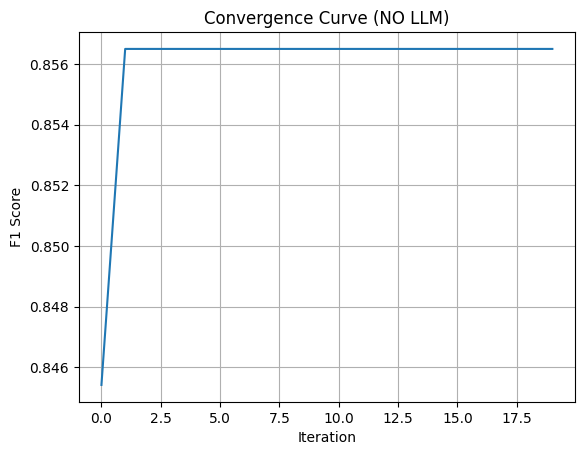

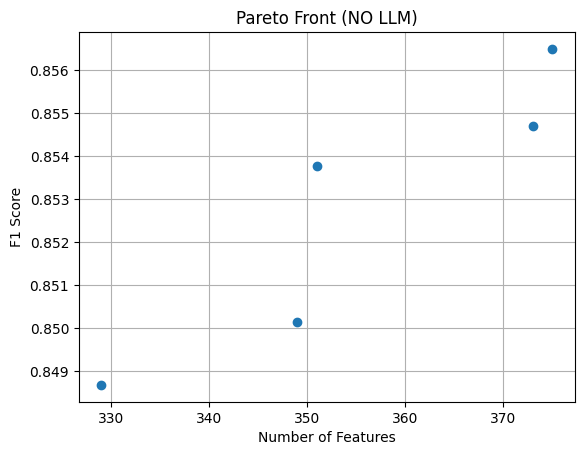

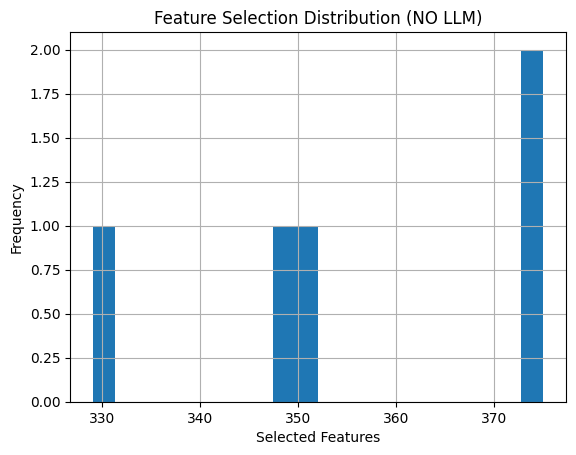


TOP SOLUTIONS:
{'solution': 0, 'features': np.int64(375), 'f1_score': np.float64(0.8564912034714632)}
{'solution': 1, 'features': np.int64(349), 'f1_score': np.float64(0.8501463704881264)}
{'solution': 2, 'features': np.int64(351), 'f1_score': np.float64(0.8537682594175624)}
{'solution': 3, 'features': np.int64(373), 'f1_score': np.float64(0.8546948773873095)}
{'solution': 4, 'features': np.int64(329), 'f1_score': np.float64(0.8486863887704758)}


In [16]:
trainfile = "parkinson/train.csv"
testfile = "parkinson/test.csv"
valfile   = "parkinson/val.csv"
n_iters = 20
pop_size = 20

options = {
    "c1": 2,
    "c2": 2,
    "w": 0.7
}

results, archive, test_f1 = MOPSO_CV(
    trainfile,
    testfile,
    valfile,
    n_iters,
    pop_size,
    options
)

print("\nTOP SOLUTIONS:")
for r in results[:5]:
    print(r)

In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# ============================================================
# LOAD DATA
# ============================================================

def load_data(train, test):
    tr = pd.read_csv(train)
    te = pd.read_csv(test)

    Xtr = tr.iloc[:, :-1].values
    ytr = tr.iloc[:, -1].values

    Xte = te.iloc[:, :-1].values
    yte = te.iloc[:, -1].values

    return Xtr, Xte, ytr, yte, tr.columns[:-1]

# ============================================================
# INITIALIZATION
# ============================================================

def init_population(n, dim):
    pos = np.random.randint(0, 2, (n, dim))
    vel = np.random.uniform(-1, 1, (n, dim))

    for i in range(n):
        if np.sum(pos[i]) == 0:
            pos[i][random.randint(0, dim-1)] = 1

    return pos, vel

# ============================================================
# FITNESS (10-FOLD CV)
# ============================================================

def fitness(p, X, y):

    if np.sum(p) == 0:
        return [1e6, 1e6]

    Xs = X[:, p == 1]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    clf = RandomForestClassifier(random_state=42)

    scores = []

    for tr, te in skf.split(Xs, y):
        clf.fit(Xs[tr], y[tr])
        pred = clf.predict(Xs[te])
        scores.append(f1_score(y[te], pred, average='weighted'))

    return [np.sum(p), -np.mean(scores)]

# ============================================================
# PARETO
# ============================================================

def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def update_archive(archive, p, f):
    new = []

    for s in archive:
        if dominates(s["f"], f):
            return archive
        if not dominates(f, s["f"]):
            new.append(s)

    new.append({"p": p.copy(), "f": f})
    return new

def select_leader(archive):
    return random.choice(archive)["p"]

# ============================================================
# PSO OPERATORS
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def velocity_update(pos, vel, pbest, leader, w, c1, c2):
    r1 = np.random.rand(len(pos))
    r2 = np.random.rand(len(pos))
    return w*vel + c1*r1*(pbest-pos) + c2*r2*(leader-pos)

def position_update(vel):
    p = (np.random.rand(len(vel)) < sigmoid(vel)).astype(int)
    if np.sum(p) == 0:
        p[np.argmax(vel)] = 1
    return p

# ============================================================
# HYPERVOLUME
# ============================================================

def hypervolume(front):
    front = np.array(front)
    front = front[front[:,0].argsort()]

    ref = [np.max(front[:,0])+10, np.max(front[:,1])+0.1]

    hv = 0
    prev = ref[1]

    for f1, f2 in front:
        w = ref[0] - f1
        h = prev - f2
        if w > 0 and h > 0:
            hv += w*h
        prev = f2

    return hv

# ============================================================
# MAIN (NO LLM)
# ============================================================

def run_mopso(train, test, iters=30, pop=20):

    X, Xte, y, yte, features = load_data(train, test)
    dim = X.shape[1]

    pos, vel = init_population(pop, dim)

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):

            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[NO LLM] Iter {it+1} | F1={best_f1:.4f}")

        for i in range(pop):
            l = select_leader(archive)
            vel[i] = velocity_update(pos[i], vel[i], pbest[i], l, 0.7, 2, 2)
            pos[i] = position_update(vel[i])

    # TEST
    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    clf = RandomForestClassifier()
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')

    hv = hypervolume([a["f"] for a in archive])

    selected_features = np.array(features)[mask == 1]

    return archive, curve, test_f1, hv, selected_features

In [3]:
import requests
import json
import re
from sklearn.preprocessing import MinMaxScaler

LLM_URL = "http://localhost:11434/api/generate"
MODEL = "llama3.2:3b"

# ============================================================
# LLM FEATURE IMPORTANCE
# ============================================================

def parse_json(raw):
    raw = raw.replace("```json","").replace("```","")
    m = re.search(r"\{[\s\S]*\}", raw)
    if not m:
        return None
    try:
        return json.loads(m.group())
    except:
        return None

def get_llm_scores(features):

    scores = {}

    for i in range(0, len(features), 30):

        batch = features[i:i+30]

        prompt = f"""
Return ONLY JSON.
Score features [0,1].

{batch}
"""

        try:
            r = requests.post(LLM_URL, json={
                "model": MODEL,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": 0}
            })

            data = parse_json(r.json()["response"])

            if data:
                for k,v in data.items():
                    try:
                        scores[k] = float(v)
                    except:
                        pass

        except:
            for f in batch:
                scores[f] = random.uniform(0.3,0.7)

    vec = np.array([scores.get(f,0.5) for f in features])
    return MinMaxScaler().fit_transform(vec.reshape(-1,1)).flatten()

# ============================================================
# LLM INIT POPULATION
# ============================================================

def init_llm(pop, dim, scores):

    P = []
    for _ in range(pop):
        p = (np.random.rand(dim) < scores).astype(int)
        if np.sum(p) == 0:
            p[np.argmax(scores)] = 1
        P.append(p)

    vel = np.random.uniform(-1,1,(pop,dim))
    return np.array(P), vel

# ============================================================
# MAIN LLM VERSION
# ============================================================

def run_mopso_llm(train, test, iters=30, pop=20):

    X, Xte, y, yte, features = load_data(train, test)
    dim = X.shape[1]

    scores = get_llm_scores(features)

    pos, vel = init_llm(pop, dim, scores)

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):

            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[LLM] Iter {it+1} | F1={best_f1:.4f}")

        for i in range(pop):
            l = select_leader(archive)
            vel[i] = velocity_update(pos[i], vel[i], pbest[i], l, 0.7, 2, 2)
            pos[i] = position_update(vel[i])

    # TEST
    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    clf = RandomForestClassifier()
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')

    hv = hypervolume([a["f"] for a in archive])

    selected_features = np.array(features)[mask == 1]

    return archive, curve, test_f1, hv, selected_features

In [4]:
train = "parkinson/train.csv"
test = "parkinson/test.csv"

A1, c1, f1_1, hv1, feat1 = run_mopso(train, test)
A2, c2, f1_2, hv2, feat2 = run_mopso_llm(train, test)

print("\nRESULTS")
print("NO LLM:", f1_1, hv1)
print("LLM   :", f1_2, hv2)

print("\nFEATURE REDUCTION")
print("NO LLM features:", len(feat1))
print("LLM features:", len(feat2))

print("\nLLM selected features:")
print(feat2)

[NO LLM] Iter 1 | F1=0.8416
[NO LLM] Iter 2 | F1=0.8416
[NO LLM] Iter 3 | F1=0.8462
[NO LLM] Iter 4 | F1=0.8462
[NO LLM] Iter 5 | F1=0.8497
[NO LLM] Iter 6 | F1=0.8518
[NO LLM] Iter 7 | F1=0.8528
[NO LLM] Iter 8 | F1=0.8528
[NO LLM] Iter 9 | F1=0.8528
[NO LLM] Iter 10 | F1=0.8543
[NO LLM] Iter 11 | F1=0.8543
[NO LLM] Iter 12 | F1=0.8543
[NO LLM] Iter 13 | F1=0.8543
[NO LLM] Iter 14 | F1=0.8543
[NO LLM] Iter 15 | F1=0.8543
[NO LLM] Iter 16 | F1=0.8543
[NO LLM] Iter 17 | F1=0.8543
[NO LLM] Iter 18 | F1=0.8543
[NO LLM] Iter 19 | F1=0.8543
[NO LLM] Iter 20 | F1=0.8543
[NO LLM] Iter 21 | F1=0.8543
[NO LLM] Iter 22 | F1=0.8543
[NO LLM] Iter 23 | F1=0.8543
[NO LLM] Iter 24 | F1=0.8543
[NO LLM] Iter 25 | F1=0.8609
[NO LLM] Iter 26 | F1=0.8609
[NO LLM] Iter 27 | F1=0.8609
[NO LLM] Iter 28 | F1=0.8609
[NO LLM] Iter 29 | F1=0.8609
[NO LLM] Iter 30 | F1=0.8609
[LLM] Iter 1 | F1=0.8432
[LLM] Iter 2 | F1=0.8527
[LLM] Iter 3 | F1=0.8527
[LLM] Iter 4 | F1=0.8527
[LLM] Iter 5 | F1=0.8527
[LLM] Iter 6 |

[NO LLM] Iter 1 | Best F1=0.8495
[NO LLM] Iter 2 | Best F1=0.8495
[NO LLM] Iter 3 | Best F1=0.8495
[NO LLM] Iter 4 | Best F1=0.8533
[NO LLM] Iter 5 | Best F1=0.8533
[NO LLM] Iter 6 | Best F1=0.8533
[NO LLM] Iter 7 | Best F1=0.8533
[NO LLM] Iter 8 | Best F1=0.8533
[NO LLM] Iter 9 | Best F1=0.8533
[NO LLM] Iter 10 | Best F1=0.8533
[NO LLM] Iter 11 | Best F1=0.8535
[NO LLM] Iter 12 | Best F1=0.8535
[NO LLM] Iter 13 | Best F1=0.8535
[NO LLM] Iter 14 | Best F1=0.8535
[NO LLM] Iter 15 | Best F1=0.8535
[NO LLM] Iter 16 | Best F1=0.8536
[NO LLM] Iter 17 | Best F1=0.8536
[NO LLM] Iter 18 | Best F1=0.8536
[NO LLM] Iter 19 | Best F1=0.8536
[NO LLM] Iter 20 | Best F1=0.8536
[NO LLM] Iter 21 | Best F1=0.8536
[NO LLM] Iter 22 | Best F1=0.8536
[NO LLM] Iter 23 | Best F1=0.8536
[NO LLM] Iter 24 | Best F1=0.8536
[NO LLM] Iter 25 | Best F1=0.8536
[NO LLM] Iter 26 | Best F1=0.8581
[NO LLM] Iter 27 | Best F1=0.8581
[NO LLM] Iter 28 | Best F1=0.8581
[NO LLM] Iter 29 | Best F1=0.8581
[NO LLM] Iter 30 | Best

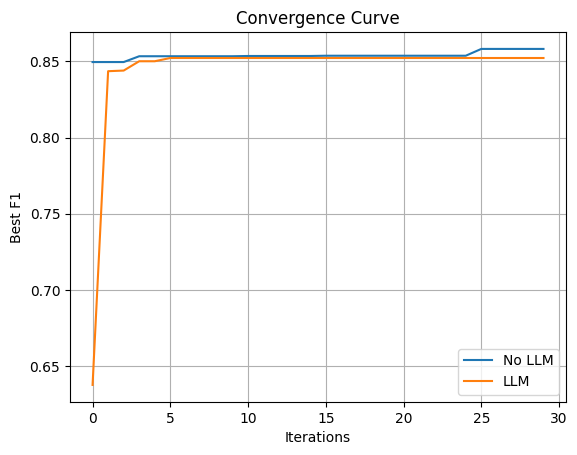

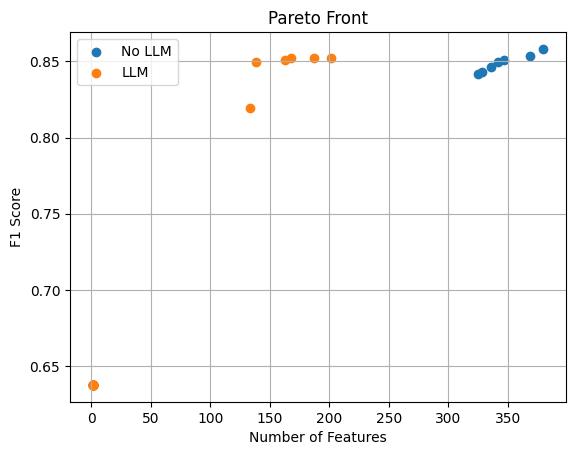

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import requests
import json
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# GLOBAL SETTINGS (REPRODUCIBILITY)
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# DATA LOADING
# ============================================================

def load_data(train_path, test_path):
    tr = pd.read_csv(train_path)
    te = pd.read_csv(test_path)

    Xtr = tr.iloc[:, :-1].values
    ytr = tr.iloc[:, -1].values

    Xte = te.iloc[:, :-1].values
    yte = te.iloc[:, -1].values

    feature_names = tr.columns[:-1].values

    return Xtr, Xte, ytr, yte, feature_names

# ============================================================
# FITNESS FUNCTION (10-FOLD CV)
# ============================================================

def fitness(mask, X, y):
    if np.sum(mask) == 0:
        return [1e6, 1e6]

    X_sel = X[:, mask == 1]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
    clf = RandomForestClassifier(random_state=SEED)

    scores = []
    for tr, te in skf.split(X_sel, y):
        clf.fit(X_sel[tr], y[tr])
        pred = clf.predict(X_sel[te])
        scores.append(f1_score(y[te], pred, average='weighted'))

    f1 = np.mean(scores)

    # OBJECTIVES:
    return [np.sum(mask), -f1]  # minimize both

# ============================================================
# PARETO LOGIC
# ============================================================

def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def update_archive(archive, p, f):
    new_archive = []

    for sol in archive:
        if dominates(sol["f"], f):
            return archive
        if not dominates(f, sol["f"]):
            new_archive.append(sol)

    new_archive.append({"p": p.copy(), "f": f})
    return new_archive

def select_leader(archive):
    return random.choice(archive)["p"]

# ============================================================
# PSO OPERATORS
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def update_velocity(pos, vel, pbest, leader, w=0.7, c1=2, c2=2):
    r1 = np.random.rand(len(pos))
    r2 = np.random.rand(len(pos))

    return w*vel + c1*r1*(pbest-pos) + c2*r2*(leader-pos)

def update_position(vel):
    p = (np.random.rand(len(vel)) < sigmoid(vel)).astype(int)

    if np.sum(p) == 0:
        p[np.argmax(vel)] = 1

    return p

# ============================================================
# HYPERVOLUME
# ============================================================

def hypervolume(front):
    front = np.array(front)
    front = front[front[:,0].argsort()]

    ref = [np.max(front[:,0]) + 10,
           np.max(front[:,1]) + 0.1]

    hv = 0
    prev = ref[1]

    for f1, f2 in front:
        w = ref[0] - f1
        h = prev - f2
        if w > 0 and h > 0:
            hv += w * h
        prev = f2

    return hv

# ============================================================
# ===================== NO LLM VERSION =======================
# ============================================================

def run_no_llm(train, test, pop=20, iters=30):

    X, Xte, y, yte, features = load_data(train, test)
    dim = X.shape[1]

    pos = np.random.randint(0, 2, (pop, dim))
    vel = np.random.uniform(-1, 1, (pop, dim))

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):
            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[NO LLM] Iter {it+1} | Best F1={best_f1:.4f}")

        for i in range(pop):
            leader = select_leader(archive)
            vel[i] = update_velocity(pos[i], vel[i], pbest[i], leader)
            pos[i] = update_position(vel[i])

    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    selected_features = features[mask == 1]

    clf = RandomForestClassifier(random_state=SEED)
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')
    hv = hypervolume([a["f"] for a in archive])

    return archive, curve, test_f1, hv, selected_features

# ============================================================
# ===================== LLM PART ==============================
# ============================================================

LLM_URL = "http://localhost:11434/api/generate"
MODEL = "llama3.2:3b"

def clean_json(text):
    text = text.replace("```json", "").replace("```", "")
    match = re.search(r"\{[\s\S]*\}", text)
    if match:
        try:
            return json.loads(match.group())
        except:
            return None
    return None

def get_llm_scores(feature_names):

    scores = {}
    batch_size = 25

    for i in range(0, len(feature_names), batch_size):
        batch = feature_names[i:i+batch_size]

        prompt = f"""
You are an expert in medical data analysis.

Assign importance scores (0 to 1).

Return ONLY JSON.

Features:
{list(batch)}
"""

        try:
            response = requests.post(
                LLM_URL,
                json={
                    "model": MODEL,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": 0}
                },
                timeout=60
            )

            raw = response.json()["response"]
            data = clean_json(raw)

            if data:
                for k, v in data.items():
                    v = float(v)
                    if 0 <= v <= 1:
                        scores[k] = v

        except:
            pass

    # fill missing
    for f in feature_names:
        if f not in scores:
            scores[f] = 0.5

    vec = np.array([scores[f] for f in feature_names])
    vec = MinMaxScaler().fit_transform(vec.reshape(-1,1)).flatten()

    return vec, scores

def show_llm_scores(features, scores):
    df = pd.DataFrame({
        "Feature": features,
        "Score": [scores[f] for f in features]
    }).sort_values(by="Score", ascending=False)

    print("\nTop LLM Features:")
    print(df.head(20))

    return df

def init_llm_population(pop, dim, scores):
    P = []
    for _ in range(pop):
        p = (np.random.rand(dim) < scores).astype(int)
        if np.sum(p) == 0:
            p[np.argmax(scores)] = 1
        P.append(p)

    vel = np.random.uniform(-1, 1, (pop, dim))
    return np.array(P), vel

# ============================================================
# ===================== LLM VERSION ===========================
# ============================================================

def run_llm(train, test, pop=20, iters=30):

    X, Xte, y, yte, features = load_data(train, test)
    dim = X.shape[1]

    scores_vec, scores_dict = get_llm_scores(features)
    show_llm_scores(features, scores_dict)

    pos, vel = init_llm_population(pop, dim, scores_vec)

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):
            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[LLM] Iter {it+1} | Best F1={best_f1:.4f}")

        for i in range(pop):
            leader = select_leader(archive)
            vel[i] = update_velocity(pos[i], vel[i], pbest[i], leader)
            pos[i] = update_position(vel[i])

    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    selected_features = features[mask == 1]

    clf = RandomForestClassifier(random_state=SEED)
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')
    hv = hypervolume([a["f"] for a in archive])

    print("\nSelected Features (LLM):", selected_features)

    return archive, curve, test_f1, hv, selected_features

# ============================================================
# ===================== MAIN EXPERIMENT ======================
# ============================================================

train = "parkinson/train.csv"
test  = "parkinson/test.csv"

A1, c1, f1_1, hv1, feat1 = run_no_llm(train, test)
A2, c2, f1_2, hv2, feat2 = run_llm(train, test)

print("\n===== FINAL RESULTS =====")
print("NO LLM  | F1:", f1_1, "| HV:", hv1, "| Features:", len(feat1))
print("LLM     | F1:", f1_2, "| HV:", hv2, "| Features:", len(feat2))

# ============================================================
# PLOTS 
# ============================================================

plt.figure()
plt.plot(c1, label="No LLM")
plt.plot(c2, label="LLM")
plt.xlabel("Iterations")
plt.ylabel("Best F1")
plt.title("Convergence Curve")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.scatter([a["f"][0] for a in A1], [-a["f"][1] for a in A1], label="No LLM")
plt.scatter([a["f"][0] for a in A2], [-a["f"][1] for a in A2], label="LLM")
plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("Pareto Front")
plt.legend()
plt.grid()
plt.show()